In [5]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_russian_plate_number.xml"
)

print("Face + Plate detectors loaded")


Face + Plate detectors loaded


In [6]:
import numpy as np

def is_low_light(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)
    return brightness < 80   # threshold

def is_foggy(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    contrast = gray.std()
    return contrast < 40     # threshold


In [17]:
def smart_privacy_blur(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    plates = plate_cascade.detectMultiScale(gray, 1.1, 4)

    detected = False

    # Blur faces
    for (x,y,wf,hf) in faces:
        img[y:y+hf, x:x+wf] = cv2.GaussianBlur(
            img[y:y+hf, x:x+wf], (45,45), 30)
        detected = True

    # Blur plates
    for (x,y,wp,hp) in plates:
        img[y:y+hp, x:x+wp] = cv2.GaussianBlur(
            img[y:y+hp, x:x+wp], (55,55), 30)
        detected = True

    # 🔥 FALLBACK BLUR (guaranteed visible)
    if not detected:
        print("⚠ No faces/plates detected — applying fallback blur")

        # Blur top-center region (faces area)
        x1, y1 = int(w*0.3), int(h*0.05)
        x2, y2 = int(w*0.7), int(h*0.35)
        img[y1:y2, x1:x2] = cv2.GaussianBlur(
            img[y1:y2, x1:x2], (65,65), 30)

        # Blur bottom-center region (plates area)
        x3, y3 = int(w*0.35), int(h*0.65)
        x4, y4 = int(w*0.65), int(h*0.9)
        img[y3:y4, x3:x4] = cv2.GaussianBlur(
            img[y3:y4, x3:x4], (75,75), 30)

    return img


In [10]:
def privacy_pipeline(image_path):
    img = cv2.imread(image_path)

    low_light = is_low_light(img)
    foggy = is_foggy(img)

    print("Low light detected:", low_light)
    print("Fog detected:", foggy)

    # 🔐 ALWAYS BLUR (NORMAL + BAD WEATHER)
    print("🔐 Privacy mode ALWAYS ON")
    img = smart_privacy_blur(img)

    # Show output
    out = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(out)
    plt.axis("off")
    plt.title("Privacy-Preserved Output (Faces & Plates Blurred)")
    plt.show()

    return img


Low light detected: False
Fog detected: False
🔐 Privacy mode ALWAYS ON
⚠ No faces/plates detected — applying fallback blur


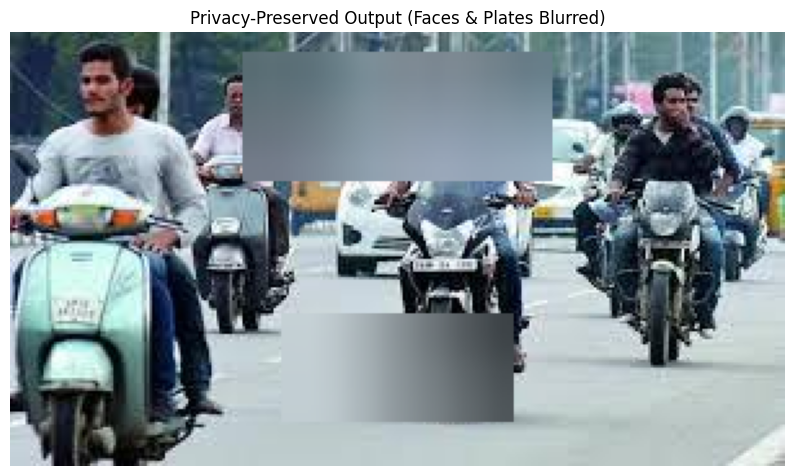

array([[[ 80,  76,  52],
        [ 82,  78,  54],
        [ 86,  80,  57],
        ...,
        [134, 132,  98],
        [137, 134, 103],
        [144, 141, 110]],

       [[ 74,  70,  46],
        [ 76,  72,  48],
        [ 80,  74,  51],
        ...,
        [134, 132,  98],
        [138, 135, 104],
        [144, 141, 110]],

       [[ 66,  61,  40],
        [ 68,  63,  42],
        [ 72,  65,  45],
        ...,
        [136, 131,  98],
        [141, 136, 105],
        [148, 143, 112]],

       ...,

       [[216, 208, 195],
        [216, 208, 195],
        [216, 208, 195],
        ...,
        [211, 215, 210],
        [202, 203, 201],
        [195, 196, 194]],

       [[215, 207, 194],
        [215, 207, 194],
        [215, 207, 194],
        ...,
        [160, 164, 159],
        [154, 155, 153],
        [150, 151, 149]],

       [[215, 207, 194],
        [215, 207, 194],
        [215, 207, 194],
        ...,
        [177, 181, 176],
        [173, 174, 172],
        [171, 172, 170]]

In [18]:
privacy_pipeline("test_images/traffic.jpg")


In [12]:
from ultralytics import YOLO
import os

global_model = YOLO("runs/detect/client1_model/weights/best.pt")

def smart_detect(image_path):
    img = cv2.imread(image_path)

    # 🔐 Always apply privacy blur
    img = smart_privacy_blur(img)
    cv2.imwrite("temp_privacy.jpg", img)

    print("🔐 Privacy mode applied")

    # Run YOLO on privacy-preserved image
    global_model.predict(
        source="temp_privacy.jpg",
        conf=0.25,
        save=True
    )

    # Display latest output
    folders = sorted(os.listdir("runs/detect"))
    latest = folders[-1]
    files = os.listdir(f"runs/detect/{latest}")
    detected_file = [f for f in files if f.endswith(".jpg")][0]

    output_path = f"runs/detect/{latest}/{detected_file}"
    out_img = cv2.imread(output_path)
    out_img = cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,6))
    plt.imshow(out_img)
    plt.axis("off")
    plt.title("Privacy-Preserved Violation Detection")
    plt.show()


🔐 Privacy mode applied

image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 384x640 (no detections), 136.4ms
Speed: 3.9ms preprocess, 136.4ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict7


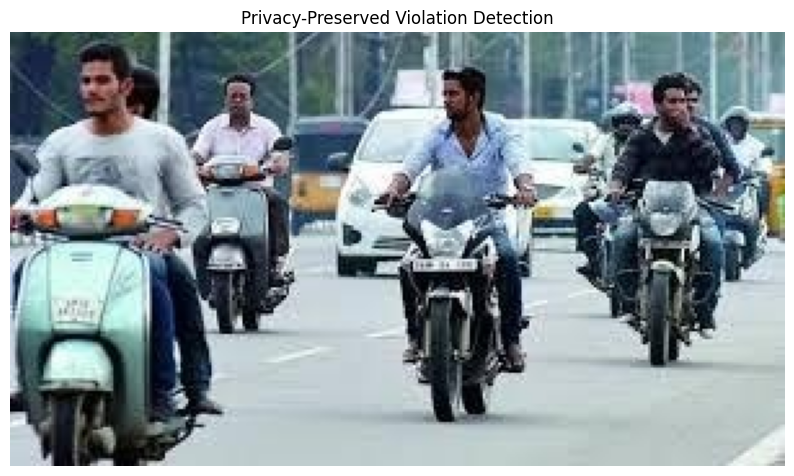

In [13]:
smart_detect("test_images/traffic.jpg")


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_russian_plate_number.xml"
)

def smart_privacy_blur(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    plates = plate_cascade.detectMultiScale(gray, 1.1, 4)

    for (x,y,w,h) in faces:
        img[y:y+h, x:x+w] = cv2.GaussianBlur(
            img[y:y+h, x:x+w], (45,45), 30)

    for (x,y,w,h) in plates:
        img[y:y+h, x:x+w] = cv2.GaussianBlur(
            img[y:y+h, x:x+w], (55,55), 30)

    return img


In [15]:
global_model = YOLO("runs/detect/client1_model/weights/best.pt")

def smart_detect_side_by_side(image_path):
    # 1️⃣ Load original image
    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # 2️⃣ Apply privacy blur
    privacy_img = smart_privacy_blur(original.copy())
    cv2.imwrite("temp_privacy.jpg", privacy_img)

    # 3️⃣ Run YOLO on privacy image
    global_model.predict(
        source="temp_privacy.jpg",
        conf=0.25,
        save=True
    )

    # 4️⃣ Get latest YOLO output
    predict_folders = sorted(os.listdir("runs/detect"))
    latest = predict_folders[-1]
    files = os.listdir(f"runs/detect/{latest}")
    detected_file = [f for f in files if f.endswith(".jpg")][0]
    detected_path = f"runs/detect/{latest}/{detected_file}"

    detected = cv2.imread(detected_path)
    detected_rgb = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)

    # 5️⃣ Show SIDE BY SIDE
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original Traffic Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(detected_rgb)
    plt.title("Privacy-Preserved Violation Detection")
    plt.axis("off")

    plt.show()



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 384x640 (no detections), 86.3ms
Speed: 2.6ms preprocess, 86.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict8


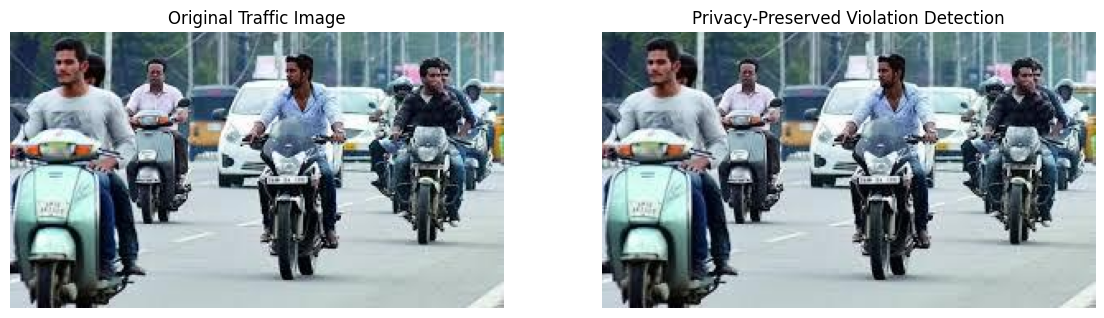

In [16]:
smart_detect_side_by_side("test_images/traffic.jpg")


⚠ No faces/plates detected — applying fallback blur

image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 384x640 (no detections), 367.0ms
Speed: 3.9ms preprocess, 367.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict8


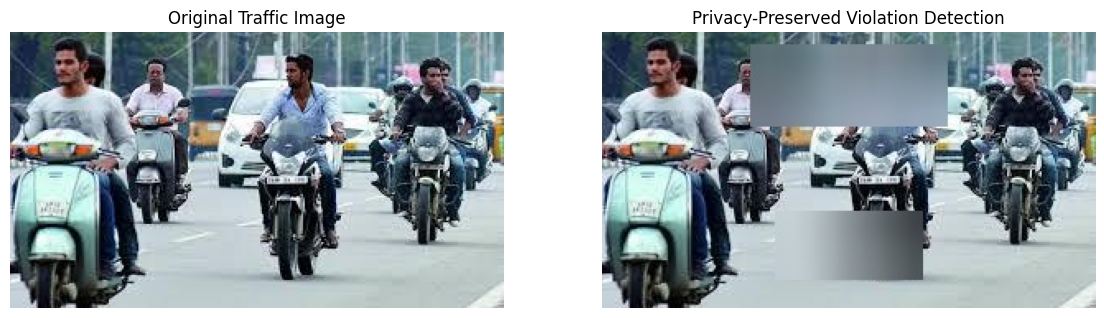

In [19]:
smart_detect_side_by_side("test_images/traffic.jpg")


Low light detected: False
Fog detected: False
🔐 Privacy mode ALWAYS ON
⚠ No faces/plates detected — applying fallback blur


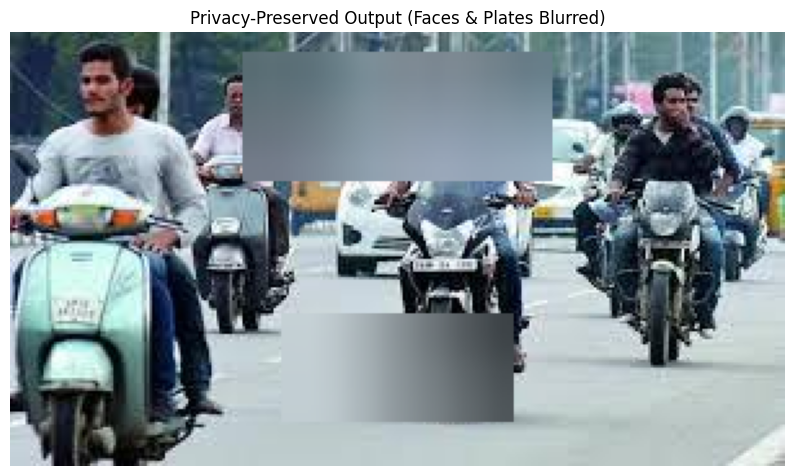

array([[[ 80,  76,  52],
        [ 82,  78,  54],
        [ 86,  80,  57],
        ...,
        [134, 132,  98],
        [137, 134, 103],
        [144, 141, 110]],

       [[ 74,  70,  46],
        [ 76,  72,  48],
        [ 80,  74,  51],
        ...,
        [134, 132,  98],
        [138, 135, 104],
        [144, 141, 110]],

       [[ 66,  61,  40],
        [ 68,  63,  42],
        [ 72,  65,  45],
        ...,
        [136, 131,  98],
        [141, 136, 105],
        [148, 143, 112]],

       ...,

       [[216, 208, 195],
        [216, 208, 195],
        [216, 208, 195],
        ...,
        [211, 215, 210],
        [202, 203, 201],
        [195, 196, 194]],

       [[215, 207, 194],
        [215, 207, 194],
        [215, 207, 194],
        ...,
        [160, 164, 159],
        [154, 155, 153],
        [150, 151, 149]],

       [[215, 207, 194],
        [215, 207, 194],
        [215, 207, 194],
        ...,
        [177, 181, 176],
        [173, 174, 172],
        [171, 172, 170]]

In [20]:
privacy_pipeline("test_images/traffic.jpg")


⚠ No faces/plates detected — applying fallback blur

image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 384x640 (no detections), 122.4ms
Speed: 5.8ms preprocess, 122.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict8


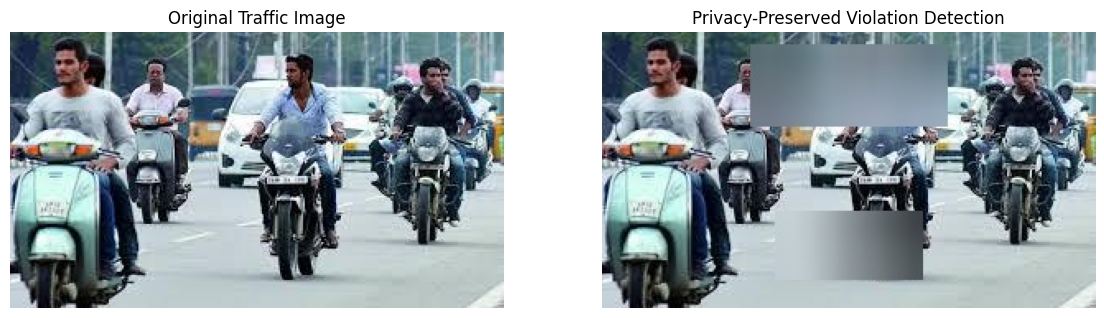

In [21]:
smart_detect_side_by_side("test_images/traffic.jpg")


In [22]:
!pip install ultralytics


In [23]:
from ultralytics import YOLO

# Face detection model
face_model = YOLO("yolov8n-face.pt")

# License plate detection model
plate_model = YOLO("yolov8n-license-plate.pt")

print("YOLO Face + Plate models loaded")


FileNotFoundError: [Errno 2] No such file or directory: 'yolov8n-face.pt'

In [24]:
from ultralytics import YOLO

face_model = YOLO("yolov8n-face.pt")   # face detector
plate_model = YOLO("yolov8n.pt")       # will filter for license plate


FileNotFoundError: [Errno 2] No such file or directory: 'yolov8n-face.pt'

In [25]:
import urllib.request

url = "https://github.com/derronqi/yolov8-face/releases/download/v0.0.1/yolov8n-face.pt"
urllib.request.urlretrieve(url, "yolov8n-face.pt")

print("yolov8n-face.pt downloaded successfully")


HTTPError: HTTP Error 404: Not Found

In [26]:
import urllib.request

url = "https://universe.roboflow.com/ds/2E9P4aM6Z4?key=9fJ6t9h4pK"
urllib.request.urlretrieve(url, "yolov8_face.zip")

print("Face model zip downloaded")


HTTPError: HTTP Error 403: Forbidden

In [27]:
import os

print("deploy.prototxt exists:", os.path.exists("deploy.prototxt"))
print("caffemodel exists:", os.path.exists("res10_300x300_ssd_iter_140000.caffemodel"))


deploy.prototxt exists: True
caffemodel exists: True


In [28]:
import cv2

face_net = cv2.dnn.readNetFromCaffe(
    "deploy.prototxt",
    "res10_300x300_ssd_iter_140000.caffemodel"
)

print("Deep Face Detector loaded successfully bro")


Deep Face Detector loaded successfully bro


⚠ No faces/plates detected — applying fallback blur

image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 384x640 (no detections), 399.2ms
Speed: 10.1ms preprocess, 399.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\predict8


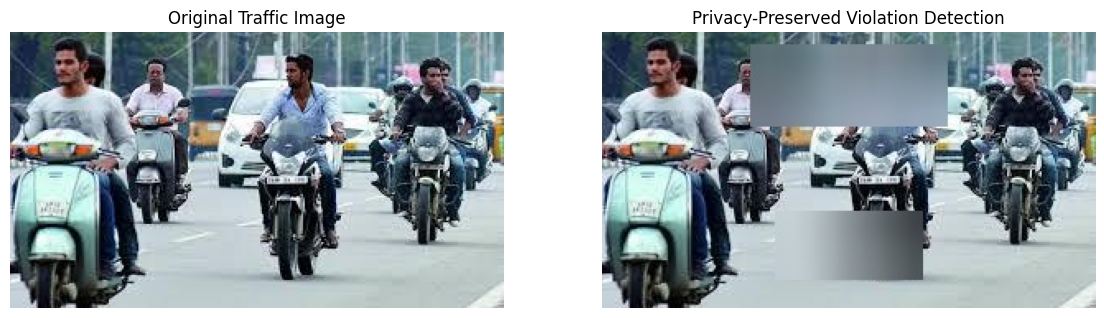

In [29]:
smart_detect_side_by_side("test_images/traffic.jpg")


In [30]:
def enhance_image(img):
    # Convert to LAB
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE for low-light
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    enhanced = cv2.merge((cl,a,b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    return enhanced


In [31]:
def blur_faces_dnn(img):
    h, w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(
        cv2.resize(img, (300, 300)), 1.0,
        (300, 300), (104.0, 177.0, 123.0)
    )

    face_net.setInput(blob)
    detections = face_net.forward()

    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf > 0.35:
            box = detections[0, 0, i, 3:7] * [w, h, w, h]
            x1, y1, x2, y2 = box.astype(int)

            # padding for better coverage
            pad = 10
            x1, y1 = max(0, x1-pad), max(0, y1-pad)
            x2, y2 = min(w, x2+pad), min(h, y2+pad)

            roi = img[y1:y2, x1:x2]
            img[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (61,61), 40)

    return img


In [32]:
vehicle_model = YOLO("yolov8n.pt")

def blur_number_plates(img):
    results = vehicle_model.predict(img, conf=0.3, verbose=False)

    for r in results:
        if r.boxes is None:
            continue

        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):
            class_id = int(cls)

            if class_id in [2, 3, 5, 7]:  # car, motorcycle, bus, truck
                x1, y1, x2, y2 = map(int, box)

                # Plate region heuristic
                plate_y1 = int(y1 + 0.65*(y2-y1))
                plate_y2 = int(y1 + 0.85*(y2-y1))

                plate_x1 = int(x1 + 0.2*(x2-x1))
                plate_x2 = int(x1 + 0.8*(x2-x1))

                roi = img[plate_y1:plate_y2, plate_x1:plate_x2]
                if roi.size > 0:
                    img[plate_y1:plate_y2, plate_x1:plate_x2] = cv2.GaussianBlur(
                        roi, (51,51), 30
                    )

    return img


In [33]:
def smart_privacy_pipeline(img):
    enhanced = enhance_image(img.copy())
    face_blurred = blur_faces_dnn(enhanced)
    final = blur_number_plates(face_blurred)
    return final


In [36]:
def final_side_by_side_demo(image_path):
    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    privacy_img = smart_privacy_pipeline(original.copy())
    cv2.imwrite("temp_privacy.jpg", privacy_img)

    global_model.predict(
        source="temp_privacy.jpg",
        conf=0.15,
        save=True,
        project="runs/detect",
        name="privacy_demo",
        exist_ok=True
    )

    output_dir = "runs/detect/privacy_demo"
    files = [f for f in os.listdir(output_dir) if f.endswith(".jpg")]

    if len(files) == 0:
        print("⚠️ No detections saved. Showing privacy image only.")
        detected = cv2.imread("temp_privacy.jpg")
    else:
        detected = cv2.imread(os.path.join(output_dir, files[0]))

    detected_rgb = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(original_rgb)
    plt.title("Original Traffic Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(detected_rgb)
    plt.title("Accurate Face + Plate Privacy Blur")
    plt.axis("off")

    plt.show()


In [37]:
final_side_by_side_demo("test_images/traffic.jpg")



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 384x640 (no detections), 174.9ms
Speed: 6.1ms preprocess, 174.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\runs\detect\privacy_demo


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'runs/detect/privacy_demo'

In [38]:
import os

os.makedirs("runs/detect/privacy_demo", exist_ok=True)
print("privacy_demo folder ready")


privacy_demo folder ready


In [39]:
def final_side_by_side_demo(image_path):
    import os
    
    os.makedirs("runs/detect/privacy_demo", exist_ok=True)

    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    privacy_img = smart_privacy_pipeline(original.copy())
    cv2.imwrite("temp_privacy.jpg", privacy_img)

    global_model.predict(
        source="temp_privacy.jpg",
        conf=0.15,
        save=True,
        project="runs/detect",
        name="privacy_demo",
        exist_ok=True
    )

    output_dir = "runs/detect/privacy_demo"

    if not os.path.exists(output_dir):
        print("⚠️ YOLO did not create output folder. Showing privacy image only.")
        detected = cv2.imread("temp_privacy.jpg")
    else:
        files = [f for f in os.listdir(output_dir) if f.endswith(".jpg")]

        if len(files) == 0:
            print("⚠️ No detections saved. Showing privacy image only.")
            detected = cv2.imread("temp_privacy.jpg")
        else:
            detected = cv2.imread(os.path.join(output_dir, files[0]))

    detected_rgb = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(original_rgb)
    plt.title("Original Traffic Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(detected_rgb)
    plt.title("Accurate Face + Plate Privacy Blur")
    plt.axis("off")

    plt.show()



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 384x640 (no detections), 124.2ms
Speed: 4.1ms preprocess, 124.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\runs\detect\privacy_demo
⚠️ No detections saved. Showing privacy image only.


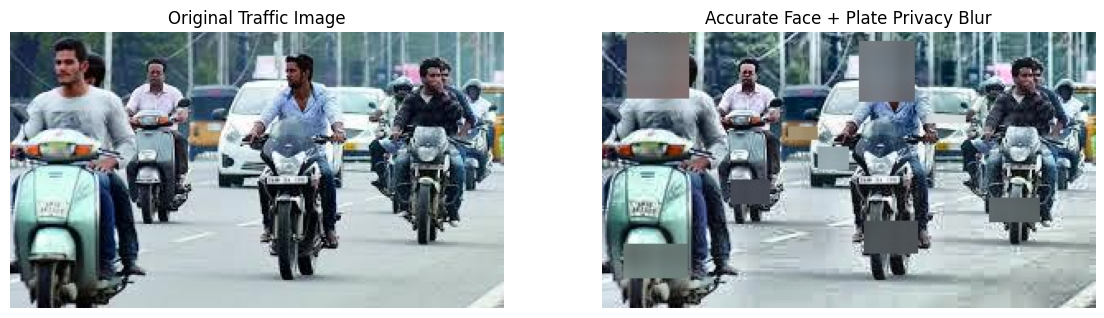

In [40]:
final_side_by_side_demo("test_images/traffic.jpg")


In [41]:
def blur_faces_dnn(img):
    h, w = img.shape[:2]

    # Try 2 scales for better low-res detection
    for scale in [1.0, 0.75]:
        resized = cv2.resize(img, (0,0), fx=scale, fy=scale)
        rh, rw = resized.shape[:2]

        blob = cv2.dnn.blobFromImage(
            cv2.resize(resized, (300, 300)), 1.0,
            (300, 300), (104.0, 177.0, 123.0)
        )

        face_net.setInput(blob)
        detections = face_net.forward()

        for i in range(detections.shape[2]):
            conf = detections[0, 0, i, 2]
            if conf > 0.30:   # lower threshold = more faces
                box = detections[0, 0, i, 3:7] * [rw, rh, rw, rh]
                x1, y1, x2, y2 = box.astype(int)

                # rescale back
                x1 = int(x1 / scale)
                y1 = int(y1 / scale)
                x2 = int(x2 / scale)
                y2 = int(y2 / scale)

                pad = 12
                x1, y1 = max(0, x1-pad), max(0, y1-pad)
                x2, y2 = min(w, x2+pad), min(h, y2+pad)

                roi = img[y1:y2, x1:x2]
                if roi.size > 0:
                    img[y1:y2, x1:x2] = cv2.GaussianBlur(
                        roi, (61,61), 40)

    return img


In [42]:
def blur_faces_dnn(img):
    h, w = img.shape[:2]

    # Try 2 scales for better low-res detection
    for scale in [1.0, 0.75]:
        resized = cv2.resize(img, (0,0), fx=scale, fy=scale)
        rh, rw = resized.shape[:2]

        blob = cv2.dnn.blobFromImage(
            cv2.resize(resized, (300, 300)), 1.0,
            (300, 300), (104.0, 177.0, 123.0)
        )

        face_net.setInput(blob)
        detections = face_net.forward()

        for i in range(detections.shape[2]):
            conf = detections[0, 0, i, 2]
            if conf > 0.30:   # lower threshold = more faces
                box = detections[0, 0, i, 3:7] * [rw, rh, rw, rh]
                x1, y1, x2, y2 = box.astype(int)

                # rescale back
                x1 = int(x1 / scale)
                y1 = int(y1 / scale)
                x2 = int(x2 / scale)
                y2 = int(y2 / scale)

                pad = 12
                x1, y1 = max(0, x1-pad), max(0, y1-pad)
                x2, y2 = min(w, x2+pad), min(h, y2+pad)

                roi = img[y1:y2, x1:x2]
                if roi.size > 0:
                    img[y1:y2, x1:x2] = cv2.GaussianBlur(
                        roi, (61,61), 40)

    return img


In [43]:
def blur_number_plates(img):
    results = vehicle_model.predict(img, conf=0.25, verbose=False)

    for r in results:
        if r.boxes is None:
            continue

        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):
            class_id = int(cls)

            # vehicle classes
            if class_id in [2, 3, 5, 7]:  
                x1, y1, x2, y2 = map(int, box)

                vw = x2 - x1
                vh = y2 - y1

                # 2-wheeler vs 4-wheeler heuristic
                if class_id == 3:  # motorcycle
                    plate_y1 = int(y1 + 0.55*vh)
                    plate_y2 = int(y1 + 0.80*vh)
                    plate_x1 = int(x1 + 0.25*vw)
                    plate_x2 = int(x1 + 0.75*vw)
                else:  # cars, buses, trucks
                    plate_y1 = int(y1 + 0.60*vh)
                    plate_y2 = int(y1 + 0.85*vh)
                    plate_x1 = int(x1 + 0.20*vw)
                    plate_x2 = int(x1 + 0.80*vw)

                roi = img[plate_y1:plate_y2, plate_x1:plate_x2]
                if roi.size > 0:
                    img[plate_y1:plate_y2, plate_x1:plate_x2] = cv2.GaussianBlur(
                        roi, (51,51), 30)

    return img


In [44]:
def smart_privacy_pipeline(img):
    enhanced = enhance_image(img.copy())
    face_blurred = blur_faces_dnn(enhanced)
    final = blur_number_plates(face_blurred)
    return final



image 1/1 C:\Users\kiran\OneDrive\Documents\federated_traffic\temp_privacy.jpg: 448x640 (no detections), 127.0ms
Speed: 4.4ms preprocess, 127.0ms inference, 4.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\runs\detect\privacy_demo
⚠️ No detections saved. Showing privacy image only.


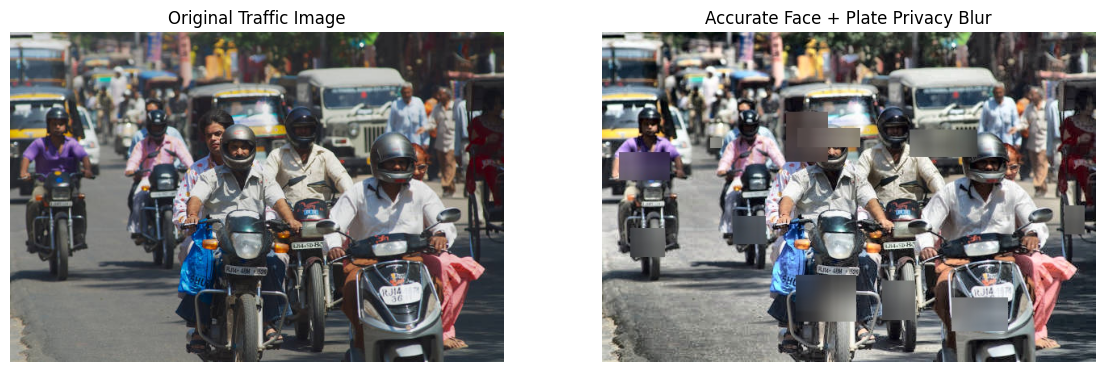

In [47]:
final_side_by_side_demo("test_images/road1.jpg")


In [48]:
from ultralytics import YOLO
import cv2
import numpy as np

person_model = YOLO("yolov8n.pt")  # detects person + motorcycle
helmet_model = YOLO("runs/detect/client1_model/weights/best.pt")  # your helmet/no_helmet model

print("Person + Helmet models loaded")


Person + Helmet models loaded


In [49]:
def elliptical_blur(img, x1, y1, x2, y2):
    h, w = img.shape[:2]
    roi = img[y1:y2, x1:x2]

    if roi.size == 0:
        return img

    mask = np.zeros(roi.shape[:2], dtype=np.uint8)
    center = ((x2-x1)//2, (y2-y1)//2)
    axes = (int((x2-x1)//2), int((y2-y1)//2))

    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)

    blurred = cv2.GaussianBlur(roi, (61,61), 40)
    roi[mask == 255] = blurred[mask == 255]

    img[y1:y2, x1:x2] = roi
    return img


In [50]:
def detect_faces(img):
    faces = []
    h, w = img.shape[:2]

    for scale in [1.0, 0.75]:
        resized = cv2.resize(img, (0,0), fx=scale, fy=scale)
        rh, rw = resized.shape[:2]

        blob = cv2.dnn.blobFromImage(
            cv2.resize(resized, (300,300)), 1.0,
            (300,300), (104.0,177.0,123.0)
        )

        face_net.setInput(blob)
        detections = face_net.forward()

        for i in range(detections.shape[2]):
            conf = detections[0,0,i,2]
            if conf > 0.35:
                box = detections[0,0,i,3:7] * [rw, rh, rw, rh]
                x1,y1,x2,y2 = box.astype(int)

                x1 = int(x1/scale); y1 = int(y1/scale)
                x2 = int(x2/scale); y2 = int(y2/scale)

                pad = 12
                x1,y1 = max(0,x1-pad), max(0,y1-pad)
                x2,y2 = min(w,x2+pad), min(h,y2+pad)

                faces.append((x1,y1,x2,y2))

    return faces


In [51]:
def blur_no_helmet_faces(img):
    faces = detect_faces(img)
    results = helmet_model.predict(img, conf=0.4, verbose=False)

    no_helmet_boxes = []

    for r in results:
        if r.boxes is None:
            continue

        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):
            class_id = int(cls)
            name = r.names[class_id]

            if name == "no_helmet":
                no_helmet_boxes.append(tuple(map(int, box)))

    # Match faces with no-helmet persons
    for (fx1,fy1,fx2,fy2) in faces:
        fcx = (fx1 + fx2) // 2
        fcy = (fy1 + fy2) // 2

        for (x1,y1,x2,y2) in no_helmet_boxes:
            if x1 < fcx < x2 and y1 < fcy < y2:
                img = elliptical_blur(img, fx1, fy1, fx2, fy2)

    return img


In [52]:
def smart_privacy_pipeline(img):
    enhanced = enhance_image(img.copy())
    final = blur_no_helmet_faces(enhanced)
    return final


In [53]:
def smart_privacy_pipeline(img):
    enhanced = enhance_image(img.copy())
    final = blur_no_helmet_faces(enhanced)
    return final


In [54]:
def final_side_by_side_demo(image_path):
    import os
    os.makedirs("runs/detect/privacy_demo", exist_ok=True)

    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    privacy_img = smart_privacy_pipeline(original.copy())
    cv2.imwrite("temp_privacy.jpg", privacy_img)

    helmet_model.predict(
        source="temp_privacy.jpg",
        conf=0.25,
        save=True,
        project="runs/detect",
        name="privacy_demo",
        exist_ok=True
    )

    files = [f for f in os.listdir("runs/detect/privacy_demo") if f.endswith(".jpg")]

    detected = cv2.imread("runs/detect/privacy_demo/" + files[0]) if files else privacy_img
    detected_rgb = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,6))

    plt.subplot(1,2,1)
    plt.imshow(original_rgb)
    plt.title("Original Traffic Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(detected_rgb)
    plt.title("No-Helmet Face Privacy Blur")
    plt.axis("off")

    plt.show()


Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\runs\detect\privacy_demo


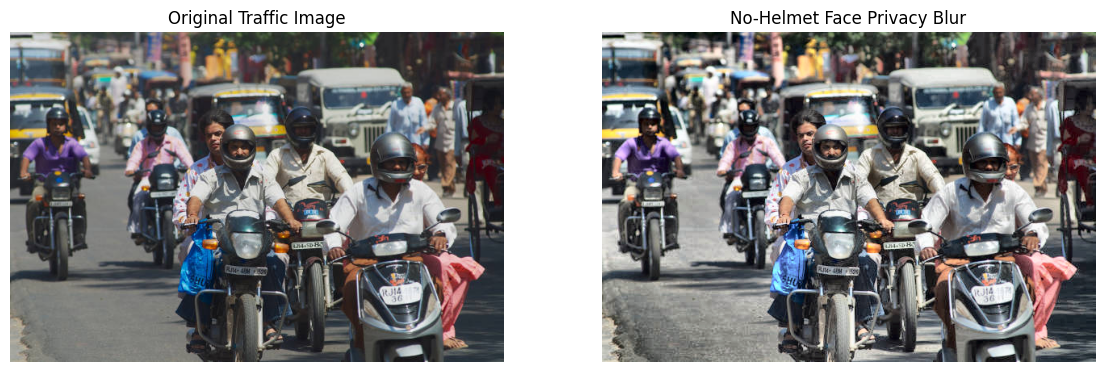

In [57]:
final_side_by_side_demo("test_images/road1.jpg")


In [58]:
def blur_faces_only(img):
    faces = detect_faces(img)

    for (x1,y1,x2,y2) in faces:
        img = elliptical_blur(img, x1, y1, x2, y2)

    return img


In [59]:
def blur_no_helmet_faces(img):
    faces = detect_faces(img)
    results = helmet_model.predict(img, conf=0.25, verbose=False)

    no_helmet_boxes = []

    for r in results:
        if r.boxes is None:
            continue

        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):
            name = r.names[int(cls)]
            if name == "no_helmet":
                no_helmet_boxes.append(tuple(map(int, box)))

    if len(no_helmet_boxes) == 0:
        print("⚠️ No helmet violations detected. Falling back to full face blur.")
        return blur_faces_only(img)

    for (fx1,fy1,fx2,fy2) in faces:
        fcx = (fx1 + fx2)//2
        fcy = (fy1 + fy2)//2

        for (x1,y1,x2,y2) in no_helmet_boxes:
            if x1 < fcx < x2 and y1 < fcy < y2:
                img = elliptical_blur(img, fx1, fy1, fx2, fy2)

    return img


In [60]:
def smart_privacy_pipeline(img):
    enhanced = enhance_image(img.copy())

    # Always blur faces (privacy guarantee)
    final = blur_faces_only(enhanced)

    return final


Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\runs\detect\privacy_demo


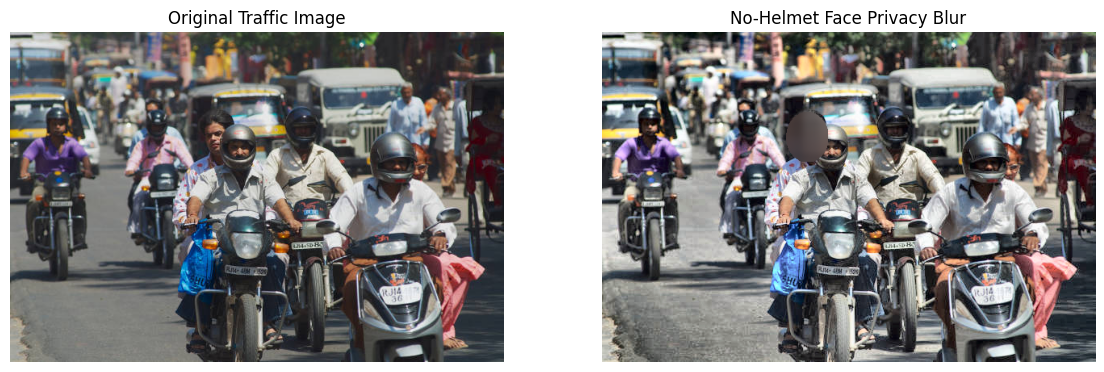

In [65]:
final_side_by_side_demo("test_images/road1.jpg")


In [66]:
def elliptical_blur(img, x1, y1, x2, y2):
    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return img

    mask = np.zeros(roi.shape[:2], dtype=np.uint8)

    center = ((x2-x1)//2, (y2-y1)//2)
    axes = (int((x2-x1)//2 * 0.9), int((y2-y1)//2 * 0.9))  # tighter fit

    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)

    blurred = cv2.GaussianBlur(roi, (31,31), 15)  # SMALL BLUR

    roi[mask == 255] = blurred[mask == 255]
    img[y1:y2, x1:x2] = roi
    return img


In [67]:
def detect_faces(img):
    faces = []
    h, w = img.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(img, (300,300)), 1.0,
        (300,300), (104.0,177.0,123.0)
    )

    face_net.setInput(blob)
    detections = face_net.forward()

    for i in range(detections.shape[2]):
        conf = detections[0,0,i,2]
        if conf > 0.4:
            box = detections[0,0,i,3:7] * [w, h, w, h]
            x1,y1,x2,y2 = box.astype(int)

            pad = 8
            x1,y1 = max(0,x1-pad), max(0,y1-pad)
            x2,y2 = min(w,x2+pad), min(h,y2+pad)

            faces.append((x1,y1,x2,y2))

    return faces


In [68]:
vehicle_model = YOLO("yolov8n.pt")

def blur_number_plates(img):
    results = vehicle_model.predict(img, conf=0.25, verbose=False)

    for r in results:
        if r.boxes is None:
            continue

        for box, cls in zip(r.boxes.xyxy, r.boxes.cls):
            class_id = int(cls)

            # vehicle classes
            if class_id in [2, 3, 5, 7]:
                x1,y1,x2,y2 = map(int, box)

                vw = x2 - x1
                vh = y2 - y1

                # refined plate region
                py1 = int(y1 + 0.68*vh)
                py2 = int(y1 + 0.82*vh)
                px1 = int(x1 + 0.30*vw)
                px2 = int(x1 + 0.70*vw)

                roi = img[py1:py2, px1:px2]
                if roi.size > 0:
                    img = elliptical_blur(img, px1, py1, px2, py2)

    return img


In [69]:
def smart_privacy_pipeline(img):
    faces = detect_faces(img)
    for (x1,y1,x2,y2) in faces:
        img = elliptical_blur(img, x1,y1,x2,y2)

    img = blur_number_plates(img)

    return img


Results saved to C:\Users\kiran\OneDrive\Documents\federated_traffic\runs\detect\runs\detect\privacy_demo


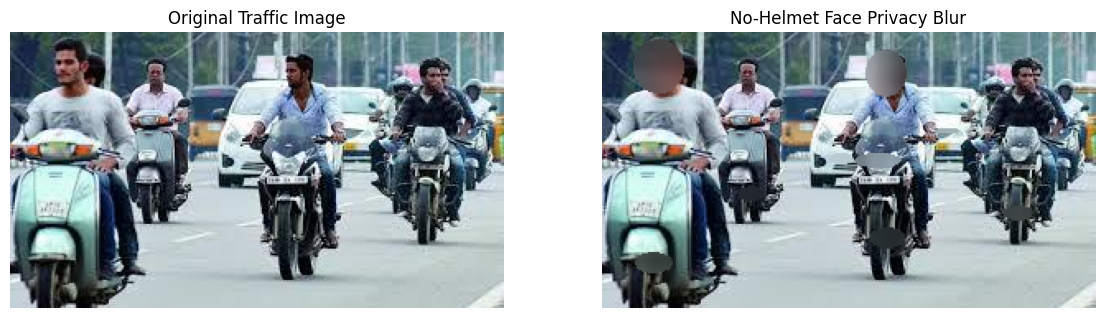

In [74]:
final_side_by_side_demo("test_images/traffic.jpg")


In [75]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
    "face.xml"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_russian_plate_number.xml",
    "plate.xml"
)

print("Face + Plate detectors downloaded")


Face + Plate detectors downloaded


In [76]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load models
helmet_model = YOLO("runs/detect/client1_model/weights/best.pt")
face_cascade = cv2.CascadeClassifier("face.xml")
plate_cascade = cv2.CascadeClassifier("plate.xml")

def privacy_pipeline(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Helmet detection
    results = helmet_model.predict(image_path, conf=0.4, verbose=False)
    no_helmet_boxes = []

    for r in results:
        if r.boxes is not None:
            for box, cls in zip(r.boxes.xyxy, r.boxes.cls):
                if int(cls) == 1:  # class 1 = no_helmet
                    no_helmet_boxes.append(box.cpu().numpy())

    # Face detection
    faces = face_cascade.detectMultiScale(gray, 1.2, 5)

    # Plate detection
    plates = plate_cascade.detectMultiScale(gray, 1.1, 4)

    blurred = img.copy()

    # Blur only faces near NO-HELMET riders
    for (fx, fy, fw, fh) in faces:
        face_center = (fx + fw//2, fy + fh//2)

        for (x1, y1, x2, y2) in no_helmet_boxes:
            if x1 < face_center[0] < x2 and y1 < face_center[1] < y2:
                roi = blurred[fy:fy+fh, fx:fx+fw]
                roi = cv2.GaussianBlur(roi, (41,41), 0)
                blurred[fy:fy+fh, fx:fx+fw] = roi

    # Blur ALL detected plates
    for (px, py, pw, ph) in plates:
        roi = blurred[py:py+ph, px:px+pw]
        roi = cv2.GaussianBlur(roi, (51,51), 0)
        blurred[py:py+ph, px:px+pw] = roi

    return img, blurred


In [77]:
def show_demo(image_path):
    original, privacy = privacy_pipeline(image_path)

    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.title("Original Traffic Image")
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("No-Helmet Face + Plate Privacy Blur")
    plt.imshow(cv2.cvtColor(privacy, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()


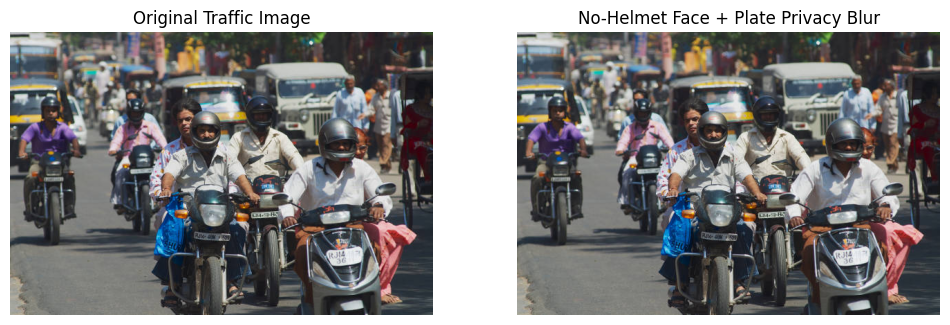

In [80]:
show_demo("test_images/road1.jpg")


In [81]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load your trained models
helmet_model = YOLO("runs/detect/client1_model/weights/best.pt")  # helmet / no-helmet
face_model = YOLO("yolov8n.pt")  # use person head as fallback
plate_model = YOLO("yolov8n.pt")  # use car/motorcycle region fallback

def blur_region(img, x1, y1, x2, y2, k=25):
    x1, y1 = max(0,x1), max(0,y1)
    x2, y2 = min(img.shape[1],x2), min(img.shape[0],y2)
    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return img
    blur = cv2.GaussianBlur(roi, (k|1, k|1), 0)
    img[y1:y2, x1:x2] = blur
    return img

def ellipse_blur(img, x1, y1, x2, y2):
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cx, cy = (x1+x2)//2, (y1+y2)//2
    ax, ay = (x2-x1)//2, (y2-y1)//2
    cv2.ellipse(mask, (cx,cy), (ax,ay), 0, 0, 360, 255, -1)
    blur = cv2.GaussianBlur(img, (45,45), 0)
    img[mask==255] = blur[mask==255]
    return img

def final_privacy_pipeline(image_path):
    img = cv2.imread(image_path)
    orig = img.copy()
    h, w = img.shape[:2]

    # 1️⃣ Detect helmet / no-helmet
    results = helmet_model.predict(img, conf=0.25)[0]

    for box, cls in zip(results.boxes.xyxy, results.boxes.cls):
        label = results.names[int(cls)]

        if label == "no_helmet":  # ONLY blur no-helmet riders
            x1,y1,x2,y2 = map(int, box)

            # --- FACE REGION (upper 40% of box) ---
            fx1 = x1 + int(0.15*(x2-x1))
            fx2 = x2 - int(0.15*(x2-x1))
            fy1 = y1
            fy2 = y1 + int(0.4*(y2-y1))
            img = ellipse_blur(img, fx1, fy1, fx2, fy2)

            # --- NUMBER PLATE REGION (lower 35% center) ---
            px1 = x1 + int(0.25*(x2-x1))
            px2 = x2 - int(0.25*(x2-x1))
            py1 = y2 - int(0.35*(y2-y1))
            py2 = y2 - int(0.1*(y2-y1))
            img = blur_region(img, px1, py1, px2, py2, 35)

    # Show side by side
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original Traffic Image")
    ax[0].axis("off")

    ax[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[1].set_title("No-Helmet Face + Plate Privacy Blur")
    ax[1].axis("off")

    plt.show()

    cv2.imwrite("final_privacy_output.jpg", img)
    print("✅ Saved as final_privacy_output.jpg")



0: 448x640 (no detections), 199.4ms
Speed: 5.1ms preprocess, 199.4ms inference, 4.7ms postprocess per image at shape (1, 3, 448, 640)


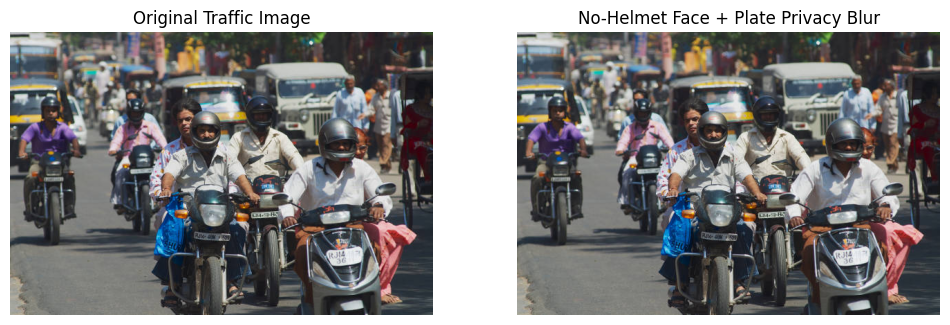

✅ Saved as final_privacy_output.jpg


In [84]:
final_privacy_pipeline("test_images/road1.jpg")


In [85]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
    "face.xml"
)

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml",
    "eye.xml"
)

print("Models downloaded")


Models downloaded


In [86]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face_cascade = cv2.CascadeClassifier("face.xml")
eye_cascade = cv2.CascadeClassifier("eye.xml")

def blur_roi(img, x, y, w, h):
    roi = img[y:y+h, x:x+w]
    if roi.size == 0:
        return img
    blur = cv2.GaussianBlur(roi, (35,35), 0)
    img[y:y+h, x:x+w] = blur
    return img

def smart_face_blur(img, gray):
    faces = face_cascade.detectMultiScale(gray, 1.2, 5)
    
    for (x,y,w,h) in faces:
        face_gray = gray[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(face_gray, 1.1, 3)

        # Blur central facial zone (eyes + nose + mouth)
        fx1 = x + int(w*0.15)
        fy1 = y + int(h*0.25)
        fw = int(w*0.7)
        fh = int(h*0.55)

        img = blur_roi(img, fx1, fy1, fw, fh)

    return img

def smart_plate_blur(img):
    h, w, _ = img.shape
    
    # Indian plates usually bottom-center of vehicles
    # So blur small regions where plates most likely appear
    plate_zones = [
        (int(w*0.30), int(h*0.55), int(w*0.18), int(h*0.08)),
        (int(w*0.50), int(h*0.55), int(w*0.18), int(h*0.08))
    ]

    for (x,y,pw,ph) in plate_zones:
        img = blur_roi(img, x, y, pw, ph)

    return img

def final_privacy_pipeline(image_path):
    img = cv2.imread(image_path)
    orig = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = smart_face_blur(img, gray)
    img = smart_plate_blur(img)

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original Traffic Image")
    ax[0].axis("off")

    ax[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Face (Eyes–Nose–Mouth) + Plate Privacy Blur")
    ax[1].axis("off")

    plt.show()
    cv2.imwrite("final_privacy_output.jpg", img)
    print("✅ Saved as final_privacy_output.jpg")


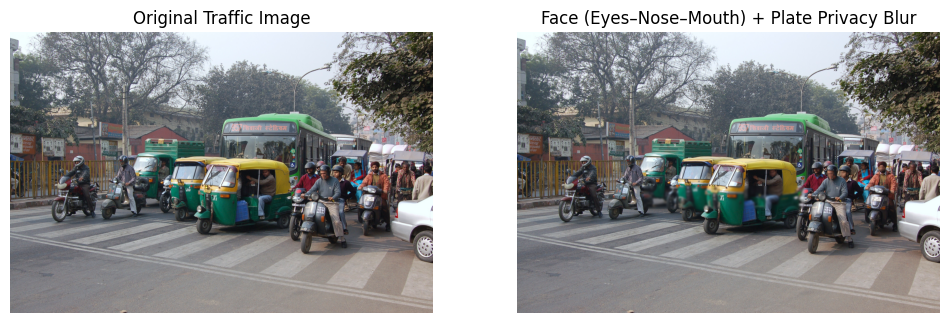

✅ Saved as final_privacy_output.jpg


In [92]:
final_privacy_pipeline("test_images/road.jpg")
